In [1]:
'''Import modules and load data'''
import sqlite3
import cudf
import pandas as pd
from tqdm import tqdm
import gc
from numba import cuda
import os
import matplotlib.pyplot as plt

os.chdir('/home/rapids/Capstone')

# From the sqlite data file import into a cudf dataframe the data from the years 2022 and 2023, from months 1 to 5 and from station_id 1 to 496
# def load_data_in_chunks(chunk_size=10000):
#     # Connect to the sqlite database
#     conn = sqlite3.connect('data.sqlite')
#     # Write query
#     query = '''SELECT * FROM data_table WHERE year IN (2022, 2023) AND month IN (1, 2, 3, 4, 5) AND station_id BETWEEN 1 AND 496'''
#     # Create a generator for chunks
#     for chunk in pd.read_sql_query(query, conn, chunksize=chunk_size):
#         # Convert the pandas chunk to a cudf dataframe
#         yield cudf.DataFrame.from_pandas(chunk)
#     # Close the connection
#     conn.close()

# # Load the data in chunks and process
# df_list = []
# for chunk in tqdm(load_data_in_chunks(chunk_size=10000)):
#     df_list.append(chunk)

# # Concatenate all chunks into a single cudf dataframe
# df = cudf.concat(df_list, ignore_index=True)

# # Print the first 5 rows
# df.head(10)

In [ ]:
# # Prepare a second dataframe with the year 2024

# def test_data_in_chunks():
#     # Connect to the sqlite database
#     conn = sqlite3.connect('data.sqlite')
#     # Write query
#     query = '''SELECT * FROM data_table WHERE year = 2024 AND month IN (1, 2, 3, 4, 5) AND station_id BETWEEN 1 AND 496'''
#     # Create a generator for chunks
#     for chunk in pd.read_sql_query(query, conn, chunksize=10000):
#         # convert the pandas chunk to a cudf dataframe
#         yield cudf.DataFrame.from_pandas(chunk)
#     # Close the connection
#     conn.close()

# # Load the data in chunks and process
# df_list = []
# for chunk in tqdm(test_data_in_chunks()):
#     df_list.append(chunk)

# # Concatenate all chunks into a single cudf dataframe
# test_df = cudf.concat(df_list, ignore_index=True)

# # Print the first 5 rows
# test_df.head(10)

177it [00:39,  4.46it/s]


,year,month,day,hour,station_id,num_bikes_available,num_bikes_available_types.mechanical,num_bikes_available_types.ebike,num_docks_available,is_installed,...,rental_uris,is_valet_station,docks_available,temperature_2m,rain,apparent_temperature,relative_humidity_2m,wind_speed_10m,sunshine_duration,timestamp
0,2024,2,1,19,19,1.083333,0.000000,1.083333,28.500000,1.0,...,<NA>,<NA>,0.950000,10.890000,0.0,9.465100,84.558044,6.877790,0.0,2024-02-01 19:00:00
1,2024,2,6,2,226,16.000000,0.000000,16.000000,11.000000,1.0,...,<NA>,<NA>,0.407407,6.540000,0.0,4.379006,94.303413,7.491114,0.0,2024-02-06 02:00:00
2,2024,2,3,22,248,10.333333,8.000000,2.333333,16.666667,1.0,...,<NA>,<NA>,0.617284,8.790000,0.0,7.422969,92.178619,5.091168,0.0,2024-02-03 22:00:00
3,2024,2,14,10,210,1.166667,0.666667,0.500000,29.833333,1.0,...,<NA>,<NA>,0.962366,12.690001,0.0,10.328749,60.284500,8.121970,3600.0,2024-02-14 10:00:00
4,2024,2,13,4,353,22.000000,15.000000,7.000000,9.000000,1.0,...,<NA>,<NA>,0.290323,7.490000,0.0,5.315050,82.715439,6.193674,0.0,2024-02-13 04:00:00
5,2024,2,11,20,79,6.083333,3.416667,2.666667,14.916667,1.0,...,<NA>,<NA>,0.621528,11.490001,0.0,7.004812,49.353512,17.555305,0.0,2024-02-11 20:00:00
6,2024,2,21,5,2,6.666667,3.666667,3.000000,21.333333,1.0,...,<NA>,<NA>,0.735632,6.890000,0.0,5.376853,95.629349,3.893995,0.0,2024-02-21 05:00:00
7,2024,2,5,14,33,14.250000,13.166667,1.083333,6.750000,1.0,...,<NA>,<NA>,0.321429,20.689999,0.0,18.511084,40.926285,9.565437,3600.0,2024-02-05 14:00:00
8,2024,2,4,1,203,2.000000,1.000000,1.000000,30.000000,1.0,...,<NA>,<NA>,0.909091,6.940000,0.0,5.023355,91.748779,5.815978,0.0,2024-02-04 01:00:00
9,2024,2,11,5,287,7.416667,7.416667,0.000000,8.583333,1.0,...,<NA>,<NA>,0.536458,9.440001,0.0,4.235621,54.384747,21.868332,0.0,2024-02-11 05:00:00


514it [00:21, 24.22it/s]


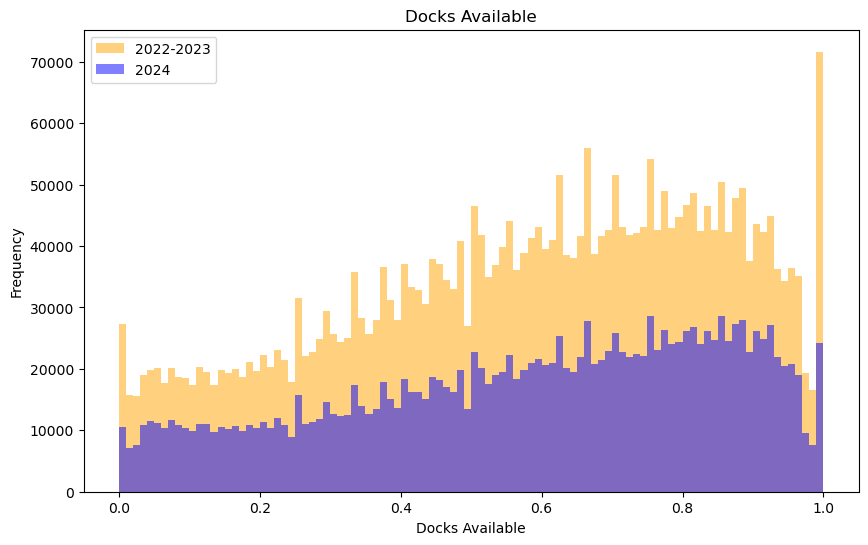

16308

In [8]:
# From the sqlite database, import the docks_available column from the data_table for the years 2022-2024, from months 1 to 5 and from station_id 1 to 496
def target_data_retrieve():
    # Make the connection to the database
    conn = sqlite3.connect('data.sqlite')
    # Write the query
    query = '''SELECT docks_available, year FROM data_table WHERE year IN (2022, 2023, 2024) AND month IN (1, 2, 3, 4, 5) AND station_id BETWEEN 1 AND 496'''
    # Read the query into a pandas dataframe
    for chunk in pd.read_sql_query(query, conn, chunksize=10000):
        yield pd.DataFrame(chunk)
    # Close the connection
    conn.close()
docks_available = pd.DataFrame()
# Load the data
for chunk in tqdm(target_data_retrieve()):
    docks_available = pd.concat([docks_available, chunk])

# Plot a histogram for the years 2022 and 2023, and another for the year 2024

plt.figure(figsize=(10, 6))
plt.hist(docks_available[docks_available['year'] != 2024]['docks_available'], bins=100, alpha=0.5, label='2022-2023', color='orange')
plt.hist(docks_available[docks_available['year'] == 2024]['docks_available'], bins=100, alpha=0.5, label='2024', color='blue')
plt.legend()
plt.title('Docks Available')
plt.xlabel('Docks Available')
plt.ylabel('Frequency')
plt.show()

# Release memory
del docks_available
gc.collect()

338it [00:41,  8.15it/s]


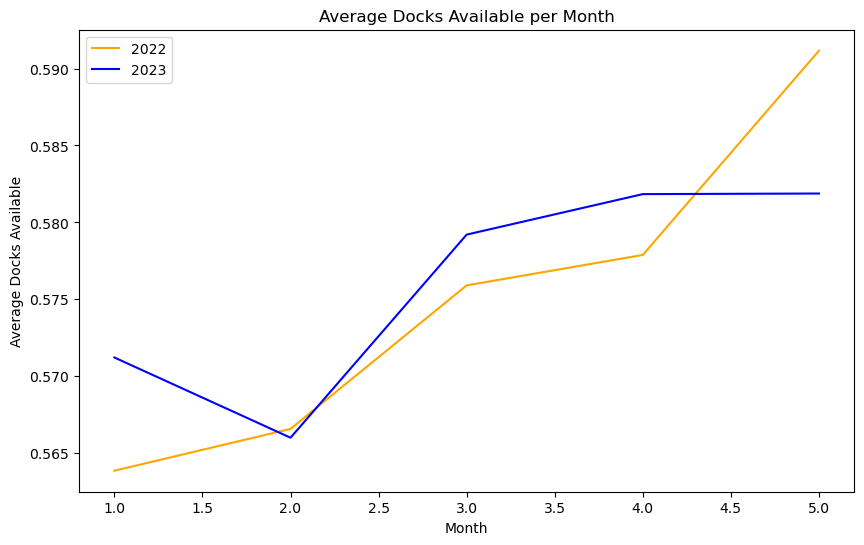

In [14]:
# Import docks_available and timestamp columns from the data_table for the years 2022-2023, from months 1 to 5 and from station_id 1 to 496

def feature_data_retrieve():
    # Make the connection to the database
    conn = sqlite3.connect('data.sqlite')
    # Write the query
    query = '''SELECT docks_available, timestamp, year, month FROM data_table WHERE year IN (2022, 2023) AND month IN (1, 2, 3, 4, 5) AND station_id BETWEEN 1 AND 496'''
    # Read the query into a pandas dataframe
    for chunk in pd.read_sql_query(query, conn, chunksize=10000):
        yield pd.DataFrame(chunk)
    # Close the connection
    conn.close()

feature_data = pd.DataFrame()

# Load the data
for chunk in tqdm(feature_data_retrieve()):
    feature_data = pd.concat([feature_data, chunk])

# Obtain the average docks_available per month for the years 2022 and 2023
feature_data['timestamp'] = pd.to_datetime(feature_data['timestamp'])
feature_data['month'] = feature_data['timestamp'].dt.month
feature_data['year'] = feature_data['timestamp'].dt.year

# Group by year and month
feature_data = feature_data.groupby(['year', 'month']).agg({'docks_available': 'mean'}).reset_index()

# Plot the average docks_available per month
plt.figure(figsize=(10, 6))
plt.plot(feature_data[feature_data['year'] == 2022]['month'], feature_data[feature_data['year'] == 2022]['docks_available'], label='2022', color='orange')
plt.plot(feature_data[feature_data['year'] == 2023]['month'], feature_data[feature_data['year'] == 2023]['docks_available'], label='2023', color='blue')
plt.legend()
plt.title('Average Docks Available per Month')
plt.xlabel('Month')
plt.ylabel('Average Docks Available')
plt.show()  


# Release memory
del feature_data
gc.collect()
cuda.current_context().deallocations.clear()
cuda.current_context().reset()

177it [00:16, 10.68it/s]


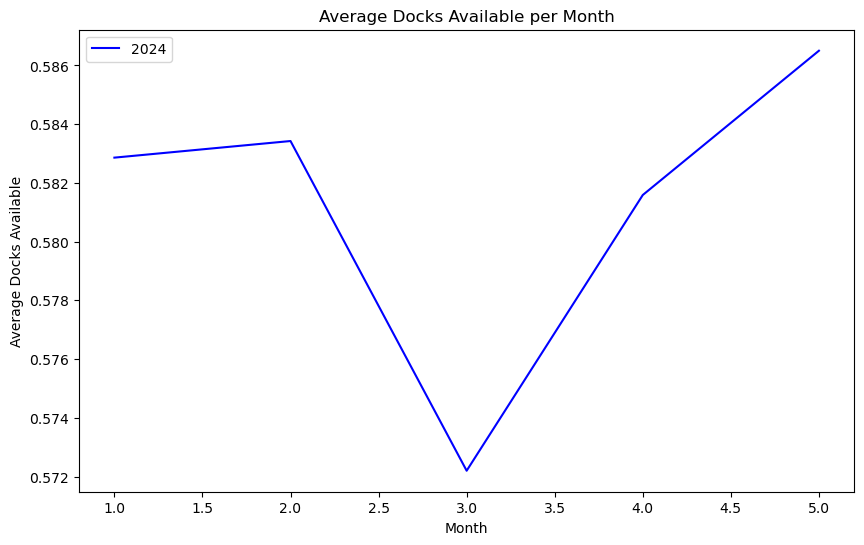

In [15]:
# Repeat the operation for 2024

def feature_data_retrieve():
    # Make the connection to the database
    conn = sqlite3.connect('data.sqlite')
    # Write the query
    query = '''SELECT docks_available, timestamp, year, month FROM data_table WHERE year = 2024 AND month IN (1, 2, 3, 4, 5) AND station_id BETWEEN 1 AND 496'''
    # Read the query into a pandas dataframe
    for chunk in pd.read_sql_query(query, conn, chunksize=10000):
        yield pd.DataFrame(chunk)
    # Close the connection
    conn.close()

feature_data = pd.DataFrame()

# Load the data
for chunk in tqdm(feature_data_retrieve()):
    feature_data = pd.concat([feature_data, chunk])

# Obtain the average docks_available per month for the year 2024
feature_data['timestamp'] = pd.to_datetime(feature_data['timestamp'])
feature_data['month'] = feature_data['timestamp'].dt.month
feature_data['year'] = feature_data['timestamp'].dt.year

# Group by year and month
feature_data = feature_data.groupby(['year', 'month']).agg({'docks_available': 'mean'}).reset_index()

# Plot the average docks_available per month
plt.figure(figsize=(10, 6))
plt.plot(feature_data[feature_data['year'] == 2024]['month'], feature_data[feature_data['year'] == 2024]['docks_available'], label='2024', color='blue')
plt.legend()
plt.title('Average Docks Available per Month')
plt.xlabel('Month')
plt.ylabel('Average Docks Available')
plt.show()

# Release memory
del feature_data
gc.collect()
cuda.current_context().deallocations.clear()
cuda.current_context().reset()